# Lab 3 — Pulse Shaping, the Nyquist Criterion and Matched Filtering

**Companion to Chapter 3.** Objectives:

1. Compare rectangular, sinc and raised-cosine pulses in time and frequency.
2. Verify the Nyquist zero-ISI criterion and see what breaks it.
3. Show that the matched filter maximizes output SNR, and why RRC is split between TX and RX.
4. Read eye diagrams: opening, timing sensitivity and noise margin.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider, Dropdown
import commlib as cl

cl.style()
rng = np.random.default_rng(3)
sps = 8

## 1. Pulse shapes and their spectra
A rectangular pulse has sinc-shaped sidelobes that decay only 6 dB/octave, so it
splatters into adjacent channels. The raised cosine with roll-off $\beta$ occupies
exactly $(1+\beta)R_s$ Hz and its impulse response decays as $1/t^3$.

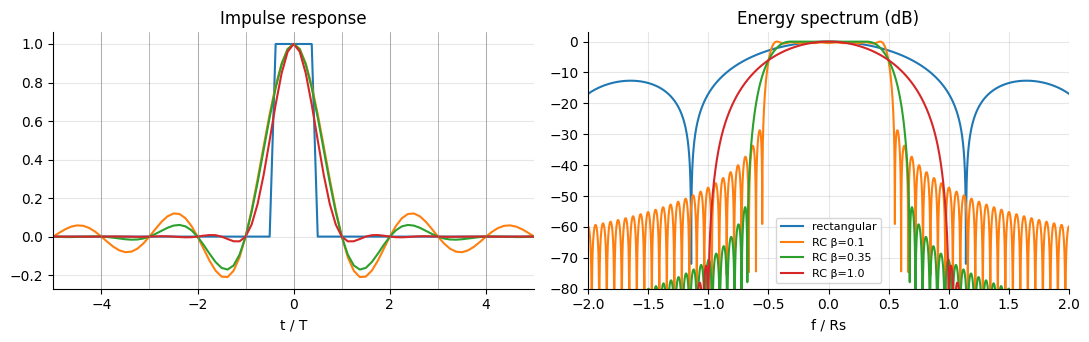

In [3]:
span = 16
t = np.arange(-span * sps / 2, span * sps / 2 + 1) / sps
pulses = {"rectangular": np.where(np.abs(t) < 0.5, 1.0, 0.0),
          "RC β=0.1": cl.rc_taps(0.1, sps, span),
          "RC β=0.35": cl.rc_taps(0.35, sps, span),
          "RC β=1.0": cl.rc_taps(1.0, sps, span)}
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
for nm, p in pulses.items():
    ax[0].plot(t, p, label=nm)
    P = np.fft.fftshift(np.abs(np.fft.fft(p, 8192)) ** 2)
    f = np.fft.fftshift(np.fft.fftfreq(8192, 1 / sps))
    ax[1].plot(f, 10 * np.log10(P / P.max() + 1e-12), label=nm)
ax[0].set_xlim(-5, 5); ax[0].set_xlabel("t / T"); ax[0].set_title("Impulse response")
for k in range(-5, 6):
    ax[0].axvline(k, color="gray", lw=0.4)
ax[1].set_xlim(-2, 2); ax[1].set_ylim(-80, 3); ax[1].set_xlabel("f / Rs"); ax[1].set_title("Energy spectrum (dB)")
ax[1].legend(fontsize=8); plt.tight_layout(); plt.show()

## 2. The Nyquist criterion: zero crossings at every other symbol
A pulse $p(t)$ gives zero ISI iff $p(kT) = \delta[k]$, equivalently
$\sum_m P(f - m/T) = T$. Above, every RC pulse crosses zero at each integer $t/T$
(grey lines). We now build a 16-QAM waveform and measure residual ISI when
the receive filter does not match the transmit filter.

In [5]:
c = cl.get_constellation("16qam")
s = c.modulate(cl.random_bits(4 * 4000, rng))

def isi_power(tx, rx):
    y = np.convolve(cl.shape(s, tx, sps), rx)
    d = int(np.argmax(np.abs(np.convolve(tx, rx))))   # peak of the end-to-end pulse
    z = y[d::sps][:len(s)]
    g = np.vdot(s, z) / np.vdot(s, s)
    return 10 * np.log10(np.mean(np.abs(z / g - s)[50:-50] ** 2))

rrc = cl.rrc_taps(0.35, sps, 12)
rc = cl.rc_taps(0.35, sps, 12); rc /= np.sqrt(np.sum(rc ** 2))
rect = np.ones(sps) / np.sqrt(sps)
print(f"RRC -> RRC            residual ISI: {isi_power(rrc, rrc):6.1f} dB")
print(f"RC  -> none (impulse) residual ISI: {isi_power(rc, np.array([1.0])):6.1f} dB")
print(f"RC  -> RC             residual ISI: {isi_power(rc, rc):6.1f} dB   (RC*RC is not Nyquist)")
print(f"rect-> rect           residual ISI: {isi_power(rect, rect):6.1f} dB")
print(f"RRC β=.35 -> RRC β=.2 residual ISI: {isi_power(rrc, cl.rrc_taps(0.2, sps, 12)):6.1f} dB (roll-off mismatch)")

RRC -> RRC            residual ISI:  -53.9 dB
RC  -> none (impulse) residual ISI: -267.5 dB
RC  -> RC             residual ISI:  -15.1 dB   (RC*RC is not Nyquist)
rect-> rect           residual ISI: -312.8 dB
RRC β=.35 -> RRC β=.2 residual ISI:  -37.9 dB (roll-off mismatch)


## 3. The matched filter maximizes SNR
For a pulse $p(t)$ in white noise, the filter $h(t) = p^*(-t)$ maximizes
the sampled output SNR at $2E_p/N_0$ (Cauchy–Schwarz). We compare the matched
filter with a simple moving-average and a wider low-pass filter.

In [7]:
from scipy.signal import firwin
def output_snr(rx, n0=1.0, trials=2000):
    p = rrc
    sig = np.convolve(p, rx)
    peak = np.max(np.abs(sig))
    noise_var = n0 * np.sum(np.abs(rx) ** 2)
    return 10 * np.log10(peak ** 2 / noise_var)
for nm, rx in [("matched RRC", rrc), ("moving average (T)", np.ones(sps) / sps),
               ("LPF cutoff 1.0 Rs", firwin(97, 1.0 / (sps / 2))), ("LPF cutoff 0.4 Rs", firwin(97, 0.4 / (sps / 2)))]:
    print(f"{nm:22s} output SNR = {output_snr(rx):6.2f} dB  (theory max = {10*np.log10(np.sum(rrc**2)):.2f} dB for N0=1)")

matched RRC            output SNR =   0.00 dB  (theory max = 0.00 dB for N0=1)
moving average (T)     output SNR =  -0.75 dB  (theory max = 0.00 dB for N0=1)
LPF cutoff 1.0 Rs      output SNR =  -2.07 dB  (theory max = 0.00 dB for N0=1)
LPF cutoff 0.4 Rs      output SNR =  -0.68 dB  (theory max = 0.00 dB for N0=1)


### Interactive: eye diagram explorer
Adjust roll-off, noise and a deliberate timing offset. The vertical eye opening
at the optimum instant is the noise margin; the horizontal opening is the
tolerance to timing jitter. Small $\beta$ saves bandwidth but closes the eye
horizontally, making the receiver more sensitive to timing error.

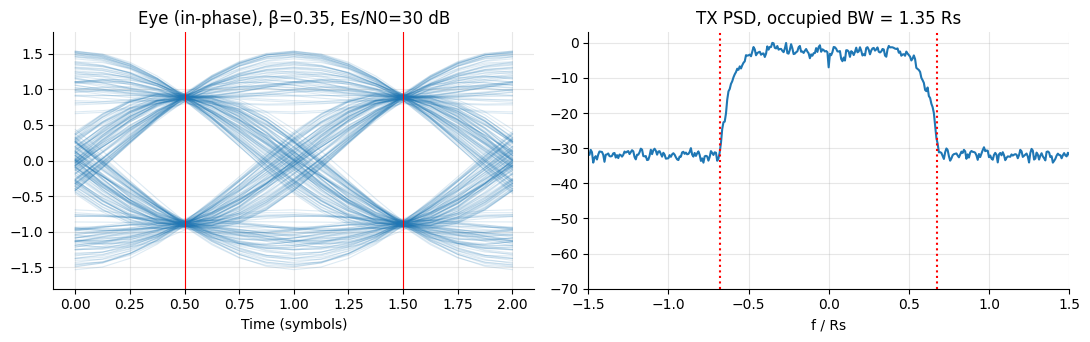

In [9]:
def eye(beta=0.35, esn0_db=30.0, mod="qpsk", tx_rx="RRC → RRC"):
    cc = cl.get_constellation(mod)
    sym = cc.modulate(cl.random_bits(cc.k * 1500, rng))
    h = cl.rrc_taps(beta, sps, 12)
    if tx_rx == "RRC → RRC":
        tx, rx = h, h
    elif tx_rx == "RC → none":
        tx = cl.rc_taps(beta, sps, 12); tx = tx / np.sqrt(np.sum(tx ** 2)); rx = np.array([1.0])
    else:
        tx, rx = h, np.ones(sps) / np.sqrt(sps)
    x = cl.shape(sym, tx, sps)
    x, _ = cl.awgn_esn0(x, esn0_db, sps=sps, rng=rng)
    y = np.convolve(x, rx)
    d = (len(tx) - 1) // 2 + (len(rx) - 1) // 2
    y = y / np.max(np.abs(y[d::sps][50:-50].real))
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
    cl.plot_eye(ax[0], y[d - sps // 2 + 100 * sps:], sps, 2)
    ax[0].axvline(0.5, color="r", lw=0.8); ax[0].axvline(1.5, color="r", lw=0.8)
    ax[0].set_title(f"Eye (in-phase), β={beta:.2f}, Es/N0={esn0_db:.0f} dB")
    ax[0].set_ylim(-1.8, 1.8)
    f, p = cl.welch_psd(x, sps, 1024)
    ax[1].plot(f, p - p.max()); ax[1].set_xlim(-1.5, 1.5); ax[1].set_ylim(-70, 3)
    ax[1].axvline((1 + beta) / 2, color="r", ls=":"); ax[1].axvline(-(1 + beta) / 2, color="r", ls=":")
    ax[1].set_xlabel("f / Rs"); ax[1].set_title(f"TX PSD, occupied BW = {(1+beta):.2f} Rs")
    plt.tight_layout(); plt.show()

interact(eye, beta=FloatSlider(value=0.35, min=0.05, max=1.0, step=0.05, description="β"),
         esn0_db=FloatSlider(value=30, min=5, max=40, step=1, description="Es/N0"),
         mod=Dropdown(options=["bpsk", "qpsk", "16qam", "64qam"], value="qpsk"),
         tx_rx=Dropdown(options=["RRC → RRC", "RC → none", "RRC → boxcar (mismatched)"]));

## 4. Timing sensitivity versus roll-off
BER of QPSK at $E_s/N_0 = 10$ dB when sampling $\epsilon T$ away from the optimum.

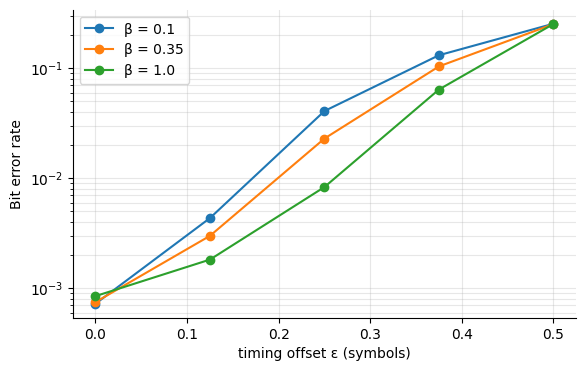

In [11]:
cq = cl.get_constellation("qpsk")
bits = cl.random_bits(2 * 20000, rng)
sym = cq.modulate(bits)
fig, ax = plt.subplots(figsize=(6.5, 4))
for beta in [0.1, 0.35, 1.0]:
    h = cl.rrc_taps(beta, sps, 16)
    y = cl.matched_filter(cl.awgn_esn0(cl.shape(sym, h, sps), 10, sps=sps, rng=rng)[0], h)
    d = len(h) - 1
    offs = np.arange(0, sps // 2 + 1)
    ber = [np.mean(cq.demodulate(y[d + o::sps][:len(sym)]) != bits) for o in offs]
    ax.semilogy(offs / sps, ber, "o-", label=f"β = {beta}")
cl.ber_axes(ax, "timing offset ε (symbols)"); ax.legend(); plt.show()

## Exercises
1. **(Warm-up)** Show that the RC spectrum satisfies the Nyquist folding condition.
2. **(Core)** Truncate the RRC to spans of 4, 6, 8 and 16 symbols and plot
   adjacent-channel leakage ratio (ACLR, power in [0.5(1+β), 1.5(1+β)]Rs over in-band power).
   What span does a 45 dB ACLR need?
3. **(Core)** Implement a polyphase interpolator that produces the RRC waveform at
   sps=8 using 8 sub-filters, and verify it matches `cl.shape` exactly.
4. **(Stretch)** Design a Nyquist pulse by least squares with a stopband constraint
   (e.g. `scipy.signal.remez` on the RRC square-root spectrum) that beats the
   truncated RRC in ACLR for the same length.